<a href="https://colab.research.google.com/github/akshay12112003/Leaf-flower-classification/blob/main/Leaf_Flower_Classification_Semester_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Problem Statement
The Lily flower, scientifically known as Lily, is a distinctive genus of flowering plants. Within this genus, there are three primary species: Tiger Lily, Asiatic Lily, and Eater Lily. These species exhibit variations in their physical characteristics, particularly in the measurements of their sepal length, sepal width, petal length, and petal width.

#Objective:

The objective of this project is to develop a machine learning model capable of learning from the measurements of Lily flowers and accurately classifying them into their respective species. The model's primary goal is to automate the classification process based on the distinct characteristics of each Lily species.

#Project Details:

Lily Species: The dataset consists of Lily flowers, specifically from the species Tiger Lily, Asiatic Lily, and Eater Lily

Key Measurements: The essential characteristics used for classification include sepal length, sepal width, petal length, and petal width.
Machine Learning Model: The project involves the creation and training of a machine learning model to accurately classify Lily flowers based on their measurements.

This project's significance lies in its potential to streamline and automate the classification of iris species, which can have broader applications in botany, horticulture, and environmental monitoring.


#IMPORTING LIBRARIES


In [ ]:
# Importing Numpy & Pandas for data processing & data wrangling
import numpy as np

# Importing  tools for visualization
import matplotlib.pyplot as pyolot
import seaborn as sns

# Import model selection libraries
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, RepeatedStratifiedKFold

import pandas as pd
%matplotlib inline

# Library used for ignore warnings
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

# LOADING THE DATASET

#What did i know about the dataset?
The lily dataset consists of length and width mesurements of sepal and petal for different species in centimeter.

No duplicate values exist.

No Null values exist.

In [ ]:
colums = ['sepal length','sepal width','petal length','petal width','class_labels']
# Load the data
df = pd.read_csv('/content/lily data set 1200 data.csv', names=colums)
df.head(1200)

,sepal length,sepal width,petal length,petal width,class_labels
0,5.1,3.5,1.4,0.2,Tiger Lily
1,4.9,3.0,1.4,0.2,Tiger Lily
2,4.7,3.2,1.3,0.2,Tiger Lily
3,4.6,3.1,1.5,0.2,Tiger Lily
4,5.0,3.6,1.4,0.2,Tiger Lily
...,...,...,...,...,...
1195,6.7,3.0,5.2,2.3,Asiatic Lily
1196,6.3,2.5,5.0,1.9,Asiatic Lily
1197,6.5,3.0,5.2,2.0,Asiatic Lily
1198,6.2,3.4,5.4,2.3,Asiatic Lily


#Dataset Rows & Columns count

In [ ]:
# Dataset Rows & Columns count
# Checking number of rows and columns of the dataset using shape
print("Number of rows are: ",df.shape[0])
print("Number of columns are: ",df.shape[1])


Number of rows are:  1200
Number of columns are:  5


#Dataset Information

In [ ]:
# Dataset Info
# Checking information about the dataset using info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal length  1200 non-null   float64
 1   sepal width   1200 non-null   float64
 2   petal length  1200 non-null   float64
 3   petal width   1200 non-null   float64
 4   class_labels  1200 non-null   object 
dtypes: float64(4), object(1)
memory usage: 47.0+ KB


#Missing Values/Null Values

In [ ]:

# Missing Values/Null Values Count
df.isnull().sum()


,0
sepal length,0
sepal width,0
petal length,0
petal width,0
class_labels,0


#VISUALIZATION THE DATASET

In [ ]:
df.describe()

,sepal length,sepal width,petal length,petal width
count,1200.000000,1200.000000,1200.000000,1200.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.825645,0.432327,1.759262,0.760930
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


#Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables

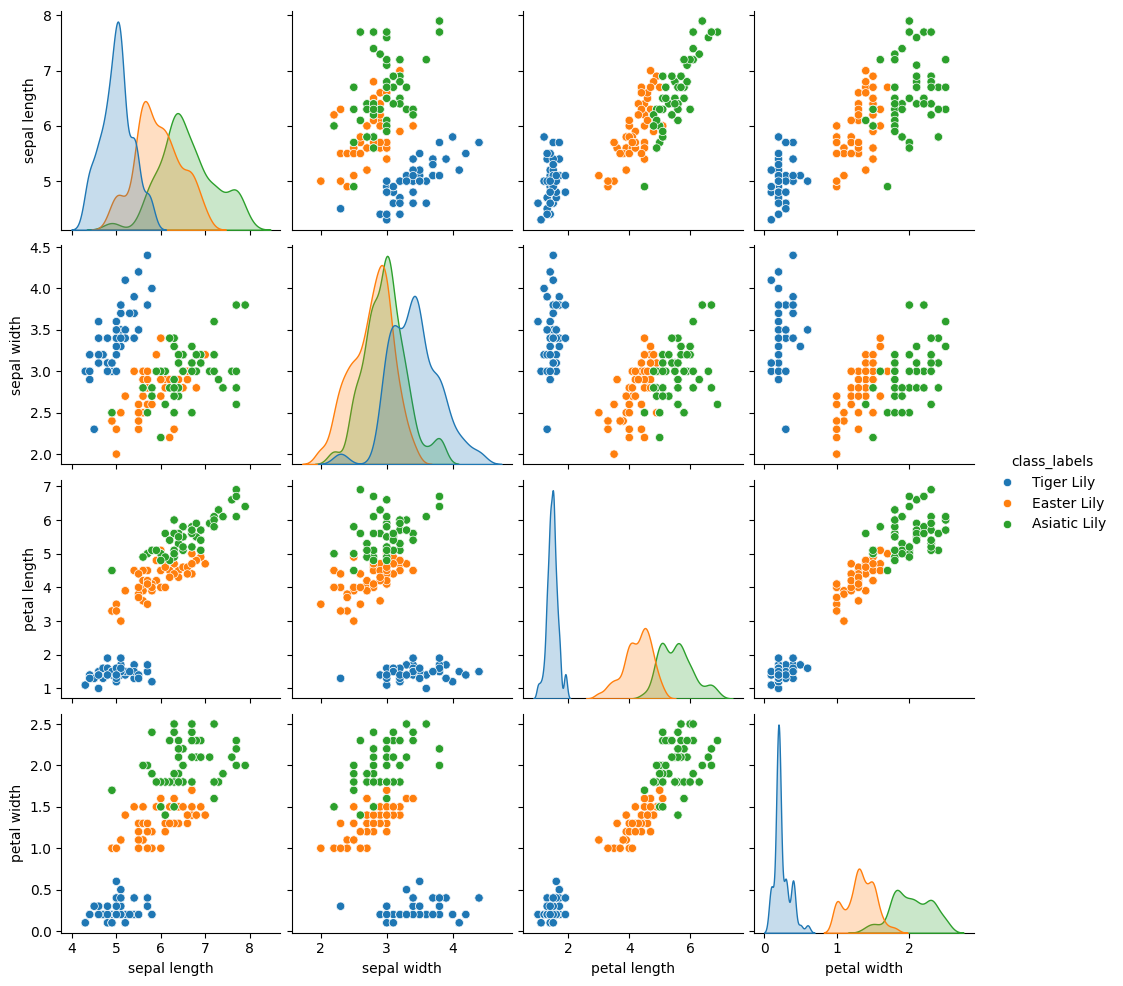

In [ ]:
# visualize the whole dataset
sns.pairplot(df , hue='class_labels')

#Correlation Heatmap

<Axes: >

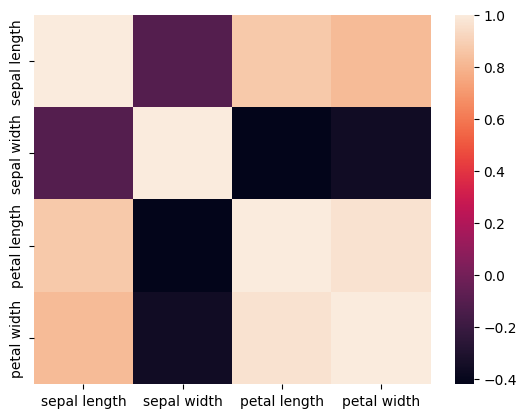

In [ ]:
# Calculate correlation only for numerical features
numerical_features = df.select_dtypes(include=['number'])  # Select only numerical columns
corr = numerical_features.corr()  # Calculate correlation for numerical features

sns.heatmap(data=corr)  # Plot the heatmap

#SEPERATING INPUT COLUMNS AND OUTPUT COLUMNS
Feature Engineering & Data Pre-processing

---




In [ ]:
#seperate features and target
data = df.values

x = data[:,0:4]
y = data[:,4]
print(y)

['Tiger Lily' 'Tiger Lily' 'Tiger Lily' ... 'Asiatic Lily '
 'Asiatic Lily ' 'Asiatic Lily ']


#SEPERATING THE DATA INTO TRANING AND TESTING

In [ ]:
#split the data to train and test dataset
from sklearn.model_selection import train_test_split
X_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2)
print(X_train)

[[5.4 3.0 4.5 1.5]
 [6.9 3.1 4.9 1.5]
 [6.3 3.3 6.0 2.5]
 ...
 [4.9 2.4 3.3 1.0]
 [5.7 3.0 4.2 1.2]
 [6.4 2.8 5.6 2.1]]


#ML Model Implementation

In [ ]:
from sklearn.model_selection import train_test_split
X_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2)
print(y_train)

['Asiatic Lily ' 'Easter Lily' 'Easter Lily' 'Tiger Lily' 'Easter Lily'
 'Easter Lily' 'Easter Lily' 'Asiatic Lily ' 'Tiger Lily' 'Easter Lily'
 'Easter Lily' 'Tiger Lily' 'Tiger Lily' 'Easter Lily' 'Easter Lily'
 'Easter Lily' 'Tiger Lily' 'Easter Lily' 'Tiger Lily' 'Asiatic Lily '
 'Easter Lily' 'Tiger Lily' 'Tiger Lily' 'Easter Lily' 'Asiatic Lily '
 'Tiger Lily' 'Tiger Lily' 'Asiatic Lily ' 'Tiger Lily' 'Tiger Lily'
 'Asiatic Lily ' 'Tiger Lily' 'Easter Lily' 'Tiger Lily' 'Easter Lily'
 'Asiatic Lily ' 'Asiatic Lily ' 'Tiger Lily' 'Easter Lily'
 'Asiatic Lily ' 'Asiatic Lily ' 'Asiatic Lily ' 'Easter Lily'
 'Asiatic Lily ' 'Easter Lily' 'Asiatic Lily ' 'Asiatic Lily '
 'Easter Lily' 'Tiger Lily' 'Tiger Lily' 'Tiger Lily' 'Easter Lily'
 'Tiger Lily' 'Tiger Lily' 'Tiger Lily' 'Tiger Lily' 'Asiatic Lily '
 'Easter Lily' 'Asiatic Lily ' 'Asiatic Lily ' 'Tiger Lily' 'Tiger Lily'
 'Easter Lily' 'Easter Lily' 'Easter Lily' 'Easter Lily' 'Asiatic Lily '
 'Easter Lily' 'Asiatic Lily ' 'Tige

In [ ]:
from sklearn.model_selection import train_test_split
X_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2)
print(x_test)

[[6.7 2.5 5.8 1.8]
 [5.7 2.8 4.5 1.3]
 [6.0 2.9 4.5 1.5]
 [5.7 3.8 1.7 0.3]
 [6.3 2.5 5.0 1.9]
 [7.6 3.0 6.6 2.1]
 [5.8 2.8 5.1 2.4]
 [6.4 3.1 5.5 1.8]
 [6.0 3.0 4.8 1.8]
 [4.9 2.5 4.5 1.7]
 [5.1 3.8 1.6 0.2]
 [7.2 3.6 6.1 2.5]
 [5.0 2.3 3.3 1.0]
 [5.7 2.6 3.5 1.0]
 [6.1 2.9 4.7 1.4]
 [5.8 2.8 5.1 2.4]
 [6.0 2.7 5.1 1.6]
 [6.7 3.0 5.2 2.3]
 [6.4 2.9 4.3 1.3]
 [6.4 3.1 5.5 1.8]
 [6.8 2.8 4.8 1.4]
 [5.0 2.0 3.5 1.0]
 [6.8 2.8 4.8 1.4]
 [4.5 2.3 1.3 0.3]
 [6.3 3.3 6.0 2.5]
 [6.9 3.1 5.1 2.3]
 [6.2 2.2 4.5 1.5]
 [5.2 3.4 1.4 0.2]
 [5.1 3.8 1.9 0.4]
 [4.9 3.1 1.5 0.1]
 [5.6 3.0 4.5 1.5]
 [4.5 2.3 1.3 0.3]
 [6.0 2.7 5.1 1.6]
 [5.2 4.1 1.5 0.1]
 [4.4 2.9 1.4 0.2]
 [7.1 3.0 5.9 2.1]
 [6.2 2.9 4.3 1.3]
 [6.1 3.0 4.9 1.8]
 [6.8 3.0 5.5 2.1]
 [5.6 3.0 4.1 1.3]
 [5.6 2.9 3.6 1.3]
 [5.6 2.8 4.9 2.0]
 [4.8 3.0 1.4 0.1]
 [5.1 3.3 1.7 0.5]
 [6.6 3.0 4.4 1.4]
 [7.4 2.8 6.1 1.9]
 [7.2 3.0 5.8 1.6]
 [7.1 3.0 5.9 2.1]
 [7.9 3.8 6.4 2.0]
 [5.7 3.0 4.2 1.2]
 [6.3 2.5 4.9 1.5]
 [5.5 2.4 3.7 1.0]
 [5.0 3.4 1.

#ML MODEL - 1 : SUPPORT VECTOR MACHINE ALGORITHM

In [ ]:
from sklearn.svm import SVC

model_svc = SVC()
model_svc.fit(X_train,y_train)

SVC()

In [ ]:
prediction1 = model_svc.predict(x_test)
#calculating the accuracy
from sklearn.metrics import accuracy_score
print(accuracy_score(y_test,prediction1)*100)
for i in range(len(prediction1)):
     print(y_test[i],prediction1[i])

99.16666666666667
Asiatic Lily  Asiatic Lily 
Easter Lily Easter Lily
Easter Lily Easter Lily
Tiger Lily Tiger Lily
Asiatic Lily  Asiatic Lily 
Asiatic Lily  Asiatic Lily 
Asiatic Lily  Asiatic Lily 
Asiatic Lily  Asiatic Lily 
Asiatic Lily  Asiatic Lily 
Asiatic Lily  Asiatic Lily 
Tiger Lily Tiger Lily
Asiatic Lily  Asiatic Lily 
Easter Lily Easter Lily
Easter Lily Easter Lily
Easter Lily Easter Lily
Asiatic Lily  Asiatic Lily 
Easter Lily Asiatic Lily 
Asiatic Lily  Asiatic Lily 
Easter Lily Easter Lily
Asiatic Lily  Asiatic Lily 
Easter Lily Easter Lily
Easter Lily Easter Lily
Easter Lily Easter Lily
Tiger Lily Tiger Lily
Asiatic Lily  Asiatic Lily 
Asiatic Lily  Asiatic Lily 
Easter Lily Easter Lily
Tiger Lily Tiger Lily
Tiger Lily Tiger Lily
Tiger Lily Tiger Lily
Easter Lily Easter Lily
Tiger Lily Tiger Lily
Easter Lily Asiatic Lily 
Tiger Lily Tiger Lily
Tiger Lily Tiger Lily
Asiatic Lily  Asiatic Lily 
Easter Lily Easter Lily
Asiatic Lily  Asiatic Lily 
Asiatic Lily  Asiatic Li

#ML MODEL - 2 : LOGISTIC REGRESSION

In [ ]:
from sklearn.linear_model import LogisticRegression
mode1_LR=LogisticRegression()
mode1_LR.fit(X_train,y_train)

LogisticRegression()

In [ ]:
prediction2 = mode1_LR.predict(x_test)
#calculating the accuracy
from sklearn.metrics import accuracy_score
print(accuracy_score(y_test,prediction2)*100)
for i in range(len(prediction2)):
     print(y_test[i],prediction2[i])

98.75
Asiatic Lily  Asiatic Lily 
Easter Lily Easter Lily
Easter Lily Easter Lily
Tiger Lily Tiger Lily
Asiatic Lily  Asiatic Lily 
Asiatic Lily  Asiatic Lily 
Asiatic Lily  Asiatic Lily 
Asiatic Lily  Asiatic Lily 
Asiatic Lily  Asiatic Lily 
Asiatic Lily  Asiatic Lily 
Tiger Lily Tiger Lily
Asiatic Lily  Asiatic Lily 
Easter Lily Easter Lily
Easter Lily Easter Lily
Easter Lily Easter Lily
Asiatic Lily  Asiatic Lily 
Easter Lily Asiatic Lily 
Asiatic Lily  Asiatic Lily 
Easter Lily Easter Lily
Asiatic Lily  Asiatic Lily 
Easter Lily Easter Lily
Easter Lily Easter Lily
Easter Lily Easter Lily
Tiger Lily Tiger Lily
Asiatic Lily  Asiatic Lily 
Asiatic Lily  Asiatic Lily 
Easter Lily Easter Lily
Tiger Lily Tiger Lily
Tiger Lily Tiger Lily
Tiger Lily Tiger Lily
Easter Lily Easter Lily
Tiger Lily Tiger Lily
Easter Lily Asiatic Lily 
Tiger Lily Tiger Lily
Tiger Lily Tiger Lily
Asiatic Lily  Asiatic Lily 
Easter Lily Easter Lily
Asiatic Lily  Asiatic Lily 
Asiatic Lily  Asiatic Lily 
Easter L

#ML MODEL 3: DECISION TREE CLASSIFIER

In [ ]:
from sklearn.tree import DecisionTreeClassifier
model_DTC=DecisionTreeClassifier()
model_DTC.fit(X_train,y_train)

DecisionTreeClassifier()

In [ ]:
prediction3 = model_svc.predict(x_test)
#calculating the accuracy
from sklearn.metrics import accuracy_score
print(accuracy_score(y_test,prediction3)*100)
for i in range(len(prediction3)):
     print(y_test[i],prediction3[i])

99.16666666666667
Asiatic Lily  Asiatic Lily 
Easter Lily Easter Lily
Easter Lily Easter Lily
Tiger Lily Tiger Lily
Asiatic Lily  Asiatic Lily 
Asiatic Lily  Asiatic Lily 
Asiatic Lily  Asiatic Lily 
Asiatic Lily  Asiatic Lily 
Asiatic Lily  Asiatic Lily 
Asiatic Lily  Asiatic Lily 
Tiger Lily Tiger Lily
Asiatic Lily  Asiatic Lily 
Easter Lily Easter Lily
Easter Lily Easter Lily
Easter Lily Easter Lily
Asiatic Lily  Asiatic Lily 
Easter Lily Asiatic Lily 
Asiatic Lily  Asiatic Lily 
Easter Lily Easter Lily
Asiatic Lily  Asiatic Lily 
Easter Lily Easter Lily
Easter Lily Easter Lily
Easter Lily Easter Lily
Tiger Lily Tiger Lily
Asiatic Lily  Asiatic Lily 
Asiatic Lily  Asiatic Lily 
Easter Lily Easter Lily
Tiger Lily Tiger Lily
Tiger Lily Tiger Lily
Tiger Lily Tiger Lily
Easter Lily Easter Lily
Tiger Lily Tiger Lily
Easter Lily Asiatic Lily 
Tiger Lily Tiger Lily
Tiger Lily Tiger Lily
Asiatic Lily  Asiatic Lily 
Easter Lily Easter Lily
Asiatic Lily  Asiatic Lily 
Asiatic Lily  Asiatic Li

# ML MODEL 4 : KNN CLASSIFIER

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
knn = KNeighborsClassifier(n_neighbors=3)

#Training knn Classifier

In [ ]:
knn.fit(X_train,y_train)

KNeighborsClassifier(n_neighbors=3)

#Evaluate model

In [ ]:
y_pred = knn.predict(x_test)
y_pred

array(['Asiatic Lily ', 'Easter Lily', 'Easter Lily', 'Tiger Lily',
       'Asiatic Lily ', 'Asiatic Lily ', 'Asiatic Lily ', 'Asiatic Lily ',
       'Asiatic Lily ', 'Asiatic Lily ', 'Tiger Lily', 'Asiatic Lily ',
       'Easter Lily', 'Easter Lily', 'Easter Lily', 'Asiatic Lily ',
       'Easter Lily', 'Asiatic Lily ', 'Easter Lily', 'Asiatic Lily ',
       'Easter Lily', 'Easter Lily', 'Easter Lily', 'Tiger Lily',
       'Asiatic Lily ', 'Asiatic Lily ', 'Easter Lily', 'Tiger Lily',
       'Tiger Lily', 'Tiger Lily', 'Easter Lily', 'Tiger Lily',
       'Easter Lily', 'Tiger Lily', 'Tiger Lily', 'Asiatic Lily ',
       'Easter Lily', 'Asiatic Lily ', 'Asiatic Lily ', 'Easter Lily',
       'Easter Lily', 'Asiatic Lily ', 'Tiger Lily', 'Tiger Lily',
       'Easter Lily', 'Asiatic Lily ', 'Asiatic Lily ', 'Asiatic Lily ',
       'Asiatic Lily ', 'Easter Lily', 'Easter Lily', 'Easter Lily',
       'Tiger Lily', 'Easter Lily', 'Tiger Lily', 'Tiger Lily',
       'Easter Lily', 'Asiatic Lil

In [ ]:
y_test

array(['Asiatic Lily ', 'Easter Lily', 'Easter Lily', 'Tiger Lily',
       'Asiatic Lily ', 'Asiatic Lily ', 'Asiatic Lily ', 'Asiatic Lily ',
       'Asiatic Lily ', 'Asiatic Lily ', 'Tiger Lily', 'Asiatic Lily ',
       'Easter Lily', 'Easter Lily', 'Easter Lily', 'Asiatic Lily ',
       'Easter Lily', 'Asiatic Lily ', 'Easter Lily', 'Asiatic Lily ',
       'Easter Lily', 'Easter Lily', 'Easter Lily', 'Tiger Lily',
       'Asiatic Lily ', 'Asiatic Lily ', 'Easter Lily', 'Tiger Lily',
       'Tiger Lily', 'Tiger Lily', 'Easter Lily', 'Tiger Lily',
       'Easter Lily', 'Tiger Lily', 'Tiger Lily', 'Asiatic Lily ',
       'Easter Lily', 'Asiatic Lily ', 'Asiatic Lily ', 'Easter Lily',
       'Easter Lily', 'Asiatic Lily ', 'Tiger Lily', 'Tiger Lily',
       'Easter Lily', 'Asiatic Lily ', 'Asiatic Lily ', 'Asiatic Lily ',
       'Asiatic Lily ', 'Easter Lily', 'Easter Lily', 'Easter Lily',
       'Tiger Lily', 'Easter Lily', 'Tiger Lily', 'Tiger Lily',
       'Easter Lily', 'Asiatic Lil

#Checking Accuracy Score

In [ ]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)
print(accuracy_score(y_test,y_pred)*100)

100.0


#A Detailed Classification Report
Selection of best model

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test,prediction2 ))

               precision    recall  f1-score   support

Asiatic Lily        0.96      1.00      0.98        78
  Easter Lily       1.00      0.97      0.98        90
   Tiger Lily       1.00      1.00      1.00        72

     accuracy                           0.99       240
    macro avg       0.99      0.99      0.99       240
 weighted avg       0.99      0.99      0.99       240



#Giving new data to our Trained ML Model

In [ ]:
x_new = np.array([[0.2,0.7,0.,0.2],[4.9,2.2,3.8,1.1],[5.3,2.5,4.6,1.9]])
# predicting of the species from inpit vector
prediction = model_svc.predict(x_new)
print("prediction os species : {}" .format(prediction))

prediction os species : ['Tiger Lily' 'Easter Lily' 'Asiatic Lily ']


#Conclusion
In the Lily flower classification project,aimed to classify lily flowers into three distinct species: Tiger Lily, Asiatic Lily, and Eater Lily. After extensive data exploration, preprocessing, and model evaluation, the following conclusions can be drawn:

Data Exploration: Through a thorough examination of the dataset, we gained insights into the characteristics and distributions of features. We found that Tiger Lily exhibited distinct features compared to the other two species.

Data Preprocessing: Data preprocessing steps, including handling missing values and encoding categorical variables, were performed to prepare the dataset for modeling.

Challenges and Future Work: The project encountered challenges related to feature engineering and model fine-tuning. Future work may involve exploring more advanced modeling techniques to improve classification accuracy further.

Practical Application: The Lily flower classification model can be applied in real-world scenarios, such as botany and horticulture, to automate the identification of Lily species based on physical characteristics.

                                                                END

#Box Plot for Feature Comparison
This graph compares the distribution of sepal length, sepal width, petal length, and petal width across the three species.

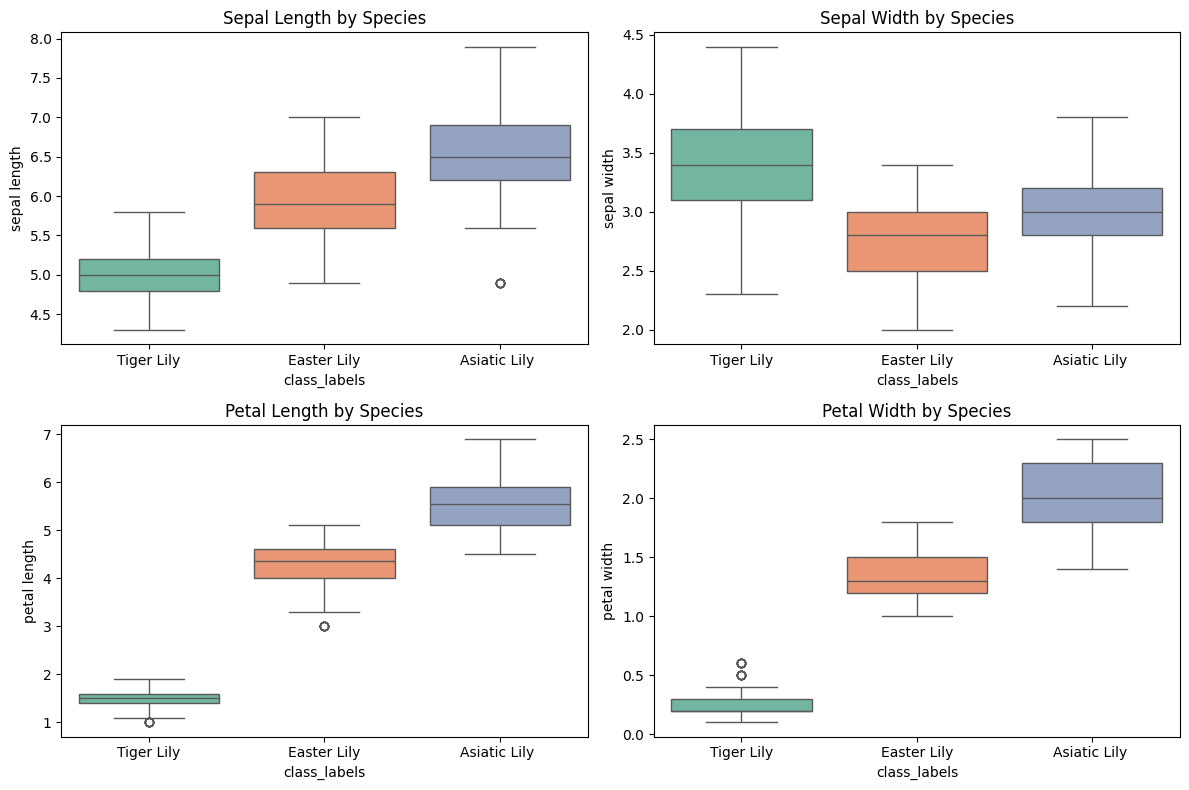

In [ ]:
plt.figure(figsize=(12, 8))

# Sepal Length
plt.subplot(2, 2, 1)
sns.boxplot(x='class_labels', y='sepal length', data=df, palette='Set2')
plt.title('Sepal Length by Species')

# Sepal Width
plt.subplot(2, 2, 2)
sns.boxplot(x='class_labels', y='sepal width', data=df, palette='Set2')
plt.title('Sepal Width by Species')

# Petal Length
plt.subplot(2, 2, 3)
sns.boxplot(x='class_labels', y='petal length', data=df, palette='Set2')
plt.title('Petal Length by Species')

# Petal Width
plt.subplot(2, 2, 4)
sns.boxplot(x='class_labels', y='petal width', data=df, palette='Set2')
plt.title('Petal Width by Species')

plt.tight_layout()
plt.show()



#Violin Plot for Feature Distribution
Violin plots provide a deeper understanding of the distribution of features across species, combining box plots and kernel density estimation.

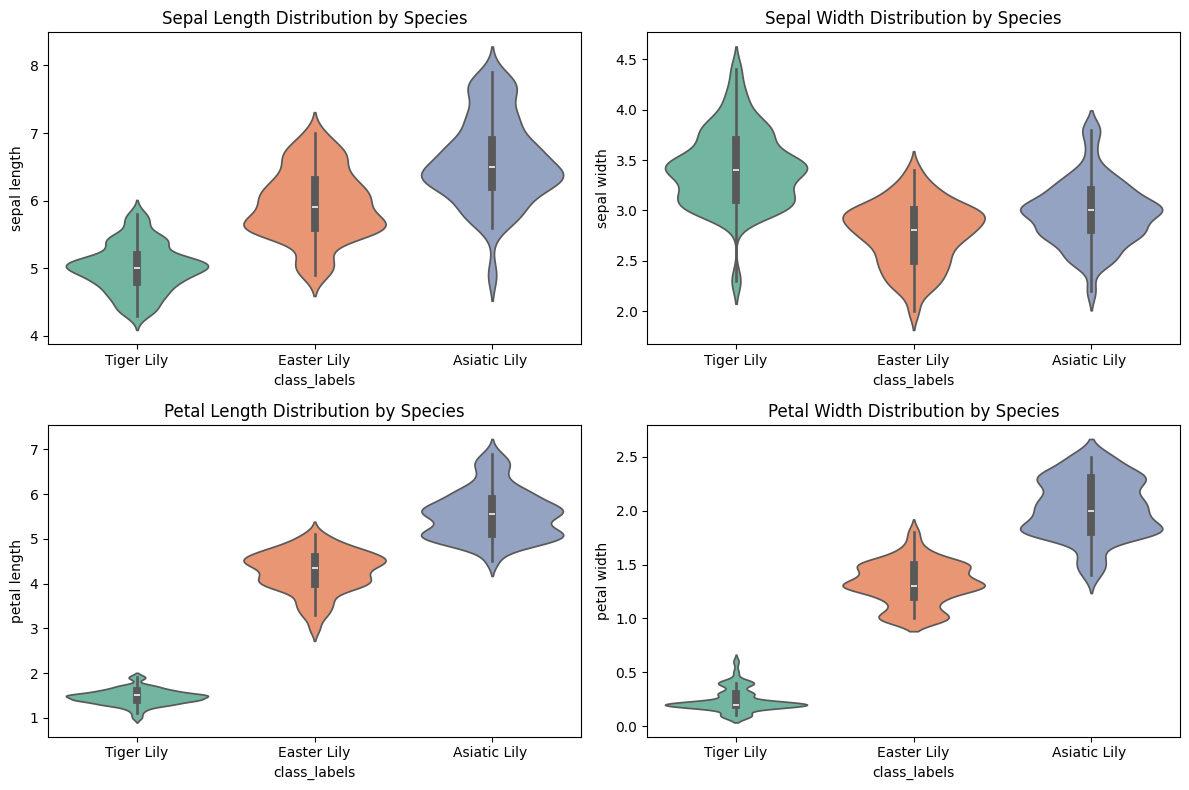

In [ ]:
plt.figure(figsize=(12, 8))

# Sepal Length
plt.subplot(2, 2, 1)
sns.violinplot(x='class_labels', y='sepal length', data=df, palette='Set2')
plt.title('Sepal Length Distribution by Species')

# Sepal Width
plt.subplot(2, 2, 2)
sns.violinplot(x='class_labels', y='sepal width', data=df, palette='Set2')
plt.title('Sepal Width Distribution by Species')

# Petal Length
plt.subplot(2, 2, 3)
sns.violinplot(x='class_labels', y='petal length', data=df, palette='Set2')
plt.title('Petal Length Distribution by Species')

# Petal Width
plt.subplot(2, 2, 4)
sns.violinplot(x='class_labels', y='petal width', data=df, palette='Set2')
plt.title('Petal Width Distribution by Species')

plt.tight_layout()
plt.show()

#Learning Curve for Model Evaluation
A learning curve shows how the model's performance improves with more training data.

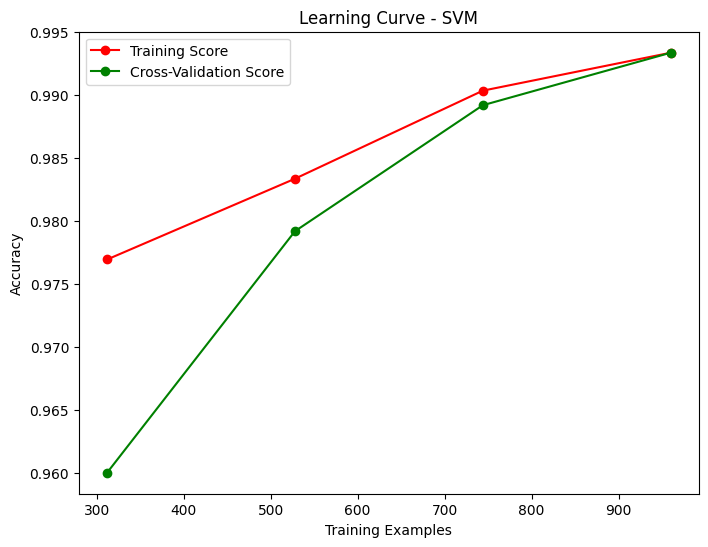

In [ ]:
from sklearn.model_selection import learning_curve
# Define a function to plot learning curves
def plot_learning_curve(estimator, title, X, y, cv=5):
    train_sizes, train_scores, test_scores = learning_curve(estimator, X, y, cv=cv, n_jobs=-1)
    train_scores_mean = train_scores.mean(axis=1)
    test_scores_mean = test_scores.mean(axis=1)

    plt.figure(figsize=(8, 6))
    plt.plot(train_sizes, train_scores_mean, 'o-', color='r', label='Training Score')
    plt.plot(train_sizes, test_scores_mean, 'o-', color='g', label='Cross-Validation Score')
    plt.title(title)
    plt.xlabel('Training Examples')
    plt.ylabel('Accuracy')
    plt.legend(loc='best')
    plt.show()

# Plot learning curve for the best model (e.g., SVM)
plot_learning_curve(model_svc, 'Learning Curve - SVM', x, y)

#Model Comparison Bar Plot
Visualize the accuracy of all models in a bar plot.

In [ ]:
from sklearn.metrics import accuracy_score

# Calculate accuracy for each model
accuracy_svm = accuracy_score(y_test, prediction1) * 100  # SVM accuracy
accuracy_lr = accuracy_score(y_test, prediction2) * 100   # Logistic Regression accuracy
accuracy_dt = accuracy_score(y_test, prediction3) * 100   # Decision Tree accuracy
accuracy_knn = accuracy_score(y_test, y_pred) * 100       # KNN accuracy

# Accuracy values
accuracies = [accuracy_svm, accuracy_lr, accuracy_dt, accuracy_knn]
models = ['SVM', 'Logistic Regression', 'Decision Tree', 'KNN']

# Plot bar plot
plt.figure(figsize=(8, 6))
sns.barplot(x=models, y=accuracies, palette='Set2')
plt.title('Model Accuracy Comparison')
plt.xlabel('Model')
plt.ylabel('Accuracy (%)')
plt.ylim(90, 90)  # Set y-axis limit for better visualization
plt.show()

NameError: name 'y_test' is not defined

#Precision-Recall Curve
A precision-recall curve is useful for imbalanced datasets and provides insights into the trade-off between precision and recall.

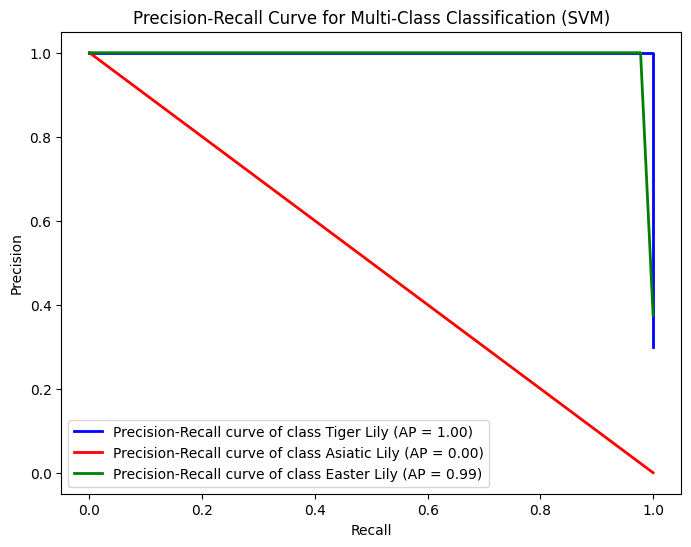

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import precision_recall_curve, average_precision_score
from itertools import cycle
import matplotlib.pyplot as plt

# Binarize the output
y_test_bin = label_binarize(y_test, classes=['Tiger Lily', 'Asiatic Lily', 'Easter Lily'])
y_pred_bin = label_binarize(prediction1, classes=['Tiger Lily', 'Asiatic Lily', 'Easter Lily'])

# Compute precision-recall curve for each class
precision = dict()
recall = dict()
average_precision = dict()
n_classes = y_test_bin.shape[1]  # Number of classes

for i in range(n_classes):
    precision[i], recall[i], _ = precision_recall_curve(y_test_bin[:, i], y_pred_bin[:, i])
    average_precision[i] = average_precision_score(y_test_bin[:, i], y_pred_bin[:, i])

# Plot precision-recall curve
plt.figure(figsize=(8, 6))
colors = cycle(['blue', 'red', 'green'])
for i, color in zip(range(n_classes), colors):
    plt.plot(recall[i], precision[i], color=color, lw=2,
             label='Precision-Recall curve of class {0} (AP = {1:0.2f})'
             .format(['Tiger Lily', 'Asiatic Lily', 'Easter Lily'][i], average_precision[i]))

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve for Multi-Class Classification (SVM)')
plt.legend(loc="lower left")
plt.show()


 #Model Accuracy Comparison Table
This table compares the accuracy of all four models.

In [ ]:
# Calculate accuracy for each model
accuracy_svm = accuracy_score(y_test, prediction1) * 100
accuracy_lr = accuracy_score(y_test, prediction2) * 100
accuracy_dt = accuracy_score(y_test, prediction3) * 100
accuracy_knn = accuracy_score(y_test, y_pred) * 100

# Create a comparison table
model_comparison = pd.DataFrame({
    'Model': ['Support Vector Machine', 'Logistic Regression', 'Decision Tree', 'KNN'],
    'Accuracy (%)': [accuracy_svm, accuracy_lr, accuracy_dt, accuracy_knn]
})

print(model_comparison)

                    Model  Accuracy (%)
0  Support Vector Machine     99.166667
1     Logistic Regression     98.750000
2           Decision Tree     99.166667
3                     KNN    100.000000


#Feature Importance Comparison Across Models
Compare feature importance across different models

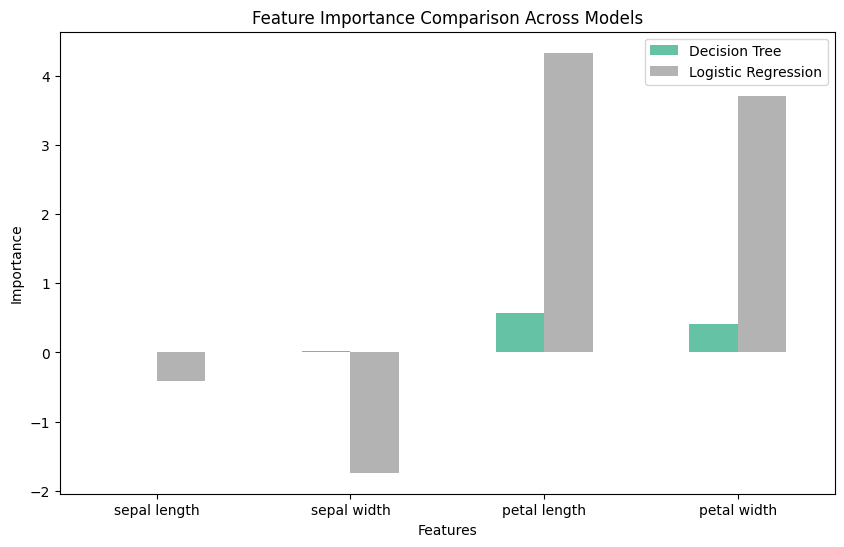

In [ ]:
# Logistic Regression coefficients
lr_coef = mode1_LR.coef_

# Create a DataFrame for feature importance comparison
feature_importance_df = pd.DataFrame({
    'Feature': df.columns[:-1],
    'Decision Tree': model_DTC.feature_importances_,
    'Logistic Regression': lr_coef[0]  # Use coefficients for Logistic Regression
})

# Plot feature importance comparison
feature_importance_df.set_index('Feature').plot(kind='bar', figsize=(10, 6), colormap='Set2')
plt.title('Feature Importance Comparison Across Models')
plt.xlabel('Features')
plt.ylabel('Importance')
plt.xticks(rotation=0)
plt.show()